In [18]:
from CASP16_NA_assessment import *
# global (capatalized variables) are defined in there
# %matplotlib inline

# Read inputs

In [19]:
rna_monomer_results_f = '../raw_scores/RNA_monomer_results_table.csv'
# read the monomer scores
df = pd.read_csv(rna_monomer_results_f)

# format the columns and add group information
df=df.astype({z:float for z in METRICS.keys()})
df['gr_code'] = df.gr_code.apply(lambda x: '0'*(3-len(str(x)))+str(x))
df['gr_code_'] = df.gr_code.copy()
df['gr_code'] = df.gr_code.apply(lambda x: GR_CODE_TO_NAME_SERVER[x] if x in GR_CODE_TO_NAME_SERVER else x)

print(df.dtypes)
print(df.target.unique())
print(len(df))
df.head()

model              object
gr_code            object
global_rmsd       float64
lddt              float64
lddt_no_checks    float64
tm_score          float64
TM_align          float64
gdt_ts            float64
inf_all           float64
inf_stack         float64
inf_wc            float64
inf_nwc           float64
clashscore        float64
clashes_number    float64
target             object
gr_code_           object
dtype: object
['R0250' 'R0251' 'R0252' 'R0253' 'R0253v1' 'R0253v2' 'R0254' 'R0281'
 'R0283' 'R0285' 'R0290' 'R1203' 'R1205' 'R1209' 'R1211' 'R1212' 'R1221s2'
 'R1221s3' 'R1224s2' 'R1224s3' 'R1242' 'R1248' 'R1250' 'R1251' 'R1252'
 'R1253v1' 'R1253v2' 'R1254' 'R1255' 'R1256' 'R1261' 'R1262' 'R1263'
 'R1264' 'R1271' 'R1281' 'R1283v1' 'R1285' 'R1286' 'R1288' 'R1289' 'R1290'
 'R1291' 'R1293' 'R1296' 'D1273' 'R1241' 'R1203v1' 'R1203v2' 'R1283v2'
 'R1283v3']
8434


,model,gr_code,global_rmsd,lddt,lddt_no_checks,tm_score,TM_align,gdt_ts,inf_all,inf_stack,inf_wc,inf_nwc,clashscore,clashes_number,target,gr_code_
0,R0250TS325_2,405 - 325,51.95,0.439,0.481,0.265,0.300,0.07,0.63,0.66,0.63,0.35,25.92,84.0,R0250,325
1,R0250TS159_2,406 - 159,51.95,0.439,0.481,0.265,0.300,0.07,0.63,0.66,0.63,0.35,25.92,84.0,R0250,159
2,R0250TS286_3,CSSB_experimental - 286,52.31,0.460,0.466,0.260,0.296,0.07,0.62,0.66,0.64,0.37,0.33,0.0,R0250,286
3,R0250TS231_1,B-LAB - 231,56.22,0.417,0.456,0.259,0.269,0.09,0.60,0.64,0.59,0.34,28.33,84.0,R0250,231
4,R0250TS317_2,GuangzhouRNA_AI - 317,50.61,0.428,0.476,0.256,0.320,0.08,0.64,0.65,0.69,0.46,28.15,91.0,R0250,317


In [20]:
print(MONOMER_TARGETS_TO_SCORE)
print(len(MONOMER_TARGETS_TO_SCORE))


['R1203', 'R1205', 'R1209', 'R1211', 'R1212', 'R1221s2', 'R1221s3', 'R1224s2', 'R1224s3', 'R1241', 'R1242', 'R1248', 'R1250', 'R1251', 'R1252', 'R1253v1', 'R1253v2', 'R1254', 'R1255', 'R1256', 'R1261', 'R1262', 'R1263', 'R1264', 'R1271', 'R1281', 'R1283v1', 'R1283v2', 'R1283v3', 'R1285', 'R1286', 'R1288', 'R1289', 'R1290', 'R1291', 'R1293', 'R1296', 'D1273']
38


In [21]:
len(df.target.unique())-9

42

In [22]:
df[df.lddt.isna()]

,model,gr_code,global_rmsd,lddt,lddt_no_checks,tm_score,TM_align,gdt_ts,inf_all,inf_stack,inf_wc,inf_nwc,clashscore,clashes_number,target,gr_code_


In [23]:
mon_grs = df.gr_code.unique()
hybrid_grs2 = ['Bhattacharya - 369', 'CoDock - 262', 'GromihaLab - 272',
       'Zheng - 462', 'MIEnsembles-Server - 110', '405 - 325',
       '406 - 159', 'AF3-server - 304', 'Vfold - 481',
       'OpenComplex_Server - 450', 'isyslab-hust - 235',
       'CSSB_experimental - 286', 'Diff - 033', 'elofsson - 241',
       'NKRNA-s - 028', 'KiharaLab - 294', 'LCBio - 189',
       'GeneSilico - 338', 'OpenComplex - 167', 'kiharalab_server - 267',
       'B-LAB - 231', 'GuangzhouRNA-human - 183',
       'GuangzhouRNA-meta - 417', 'GuangzhouRNA_AI - 317',
       'RNApolis - 063', 'OmniFold - 400', 'falcon2 - 208',
       'dMNAfold - 143', 'dNAfold - 448', 'Huang-HUST - 091',
       'RNA_Dojo - 006', '225', '044', 'Pcons - 471', '489', '204', '323',
       '014', '022', 'Zheng-Multimer - 147', 'MULTICOM - 051',
       'MULTICOM_human - 345', '274', 'MULTICOM_LLM - 319',
       'MULTICOM_GATE - 425', 'MULTICOM_AI - 331']
mulrimer = ['CoDock - 262', 'AF3-server - 304', 'OpenComplex_Server - 450',
       'NKRNA-s - 028', 'Zheng - 462', 'MIEnsembles-Server - 110',
       'Vfold - 481', 'GromihaLab - 272', 'elofsson - 241', 'LCBio - 189',
       'OpenComplex - 167', 'falcon2 - 208', 'KiharaLab - 294',
       'CSSB_experimental - 286', 'SoutheRNA - 156',
       'GuangzhouRNA_AI - 317', 'GuangzhouRNA-meta - 417',
       'Yang-Server - 052', 'GuangzhouRNA-human - 183',
       'Bhattacharya - 369', 'Diff - 033', '406 - 159', 'B-LAB - 231',
       '405 - 325', 'GeneSilico - 338', 'isyslab-hust - 235',
       'RNAFOLDX - 435', 'dNAfold - 448', 'dMNAfold - 143',
       'kiharalab_server - 267', 'Huang-HUST - 091', 'RNApolis - 063']
print([x for x in hybrid_grs2 if x not in mon_grs])
print([x for x in mulrimer if x not in mon_grs])
print(len(mon_grs))

['MIEnsembles-Server - 110', 'AF3-server - 304', 'OpenComplex_Server - 450', 'NKRNA-s - 028', 'kiharalab_server - 267', 'falcon2 - 208', 'Pcons - 471', '489', '204', '323', '014', '022', 'Zheng-Multimer - 147', '274', 'MULTICOM_LLM - 319', 'MULTICOM_GATE - 425', 'MULTICOM_AI - 331']
['AF3-server - 304', 'OpenComplex_Server - 450', 'NKRNA-s - 028', 'MIEnsembles-Server - 110', 'falcon2 - 208', 'Yang-Server - 052', 'kiharalab_server - 267']
69


In [24]:
mon_grs = ['405 - 325', '406 - 159', 'CSSB_experimental - 286', 'B-LAB - 231',
       'GuangzhouRNA_AI - 317', 'falcon2 - 208', 'RNAFOLDX - 435',
       'GuangzhouRNA-meta - 417', 'KiharaLab - 294', 'Bhattacharya - 369',
       'GromihaLab - 272', 'GuangzhouRNA-human - 183', 'Vfold - 481',
       'SoutheRNA - 156', 'Diff - 033', 'CoDock - 262',
       'isyslab-hust - 235', 'LCBio - 189', 'elofsson - 241',
       'RNApolis - 063', 'OpenComplex - 167', 'OpenComplex_Server - 450',
       'NKRNA-s - 028', 'Zheng - 462', 'AF3-server - 304',
       'MIEnsembles-Server - 110', 'GeneSilico - 338',
       'Yang-Server - 052', 'Yang-Multimer - 456', 'thermomaps - 169',
       'kiharalab_server - 267', 'dNAfold - 448',
       'GeneSilicoRNA-server - 306', 'SimRNA-server - 094', 'BRIQX - 238',
       'dfr - 165', 'RNA_Dojo - 006', 'Dokholyan - 439', 'nfRNA - 307',
       'OmniFold - 400', 'FrederickFolding - 276', 'AIR - 367',
       'mmagnus - 403', 'ShanghaiTech-server - 423',
       'ShanghaiTech-human - 298', 'PerezLab_Gators - 358', 'UNRES - 261',
       'Huang-HUST - 091', '044', '225', 'dMNAfold - 143', 'Pcons - 471',
       'UDMod - 447', 'LCDD-team - 055', 'comppharmunibas - 020',
       'SNU-CHEM-lig - 408', 'test001 - 202', 'PocketTracer - 464',
       'KUMC - 227', 'MULTICOM_ligand - 207', 'SwRI - 026',
       'Zheng-Multimer - 147', 'MULTICOM - 051', 'MULTICOM_human - 345',
       'MULTICOM_AI - 331', 'MULTICOM_GATE - 425', 'MULTICOM_LLM - 319']
print(len(mon_grs))
# ligand and mulimter are within this list

67


# Rankings

In [25]:
# reduce to one (best) score per group per target
columns = ['target', 'gr_code']
best1_df = reduce_df(df, score_to_choice_best=None,
               static_columns=columns, metric_dict=METRICS,
                participipation_cutoff=PARTICIPATION_RATE,participation_score='tm_score',
              participation_targets=MONOMER_TARGETS_TO_SCORE)
# on the one model per group per target, calculate Z-scores for each metric
temp_dfs = []
for target in MONOMER_TARGETS_TO_SCORE:
    target_df = best1_df[best1_df.target==target].copy()
    for metric in METRICS.keys():
        # if ('inf' in metric and target in ['D1273','R1286']) or (metric == 'clashscore' and target in ['R1286']):
        if ('inf' in metric and target == 'D1273'):
            target_df["Z_"+metric] = 0
        else:
            target_df["Z_"+metric] = get_zscore(target_df[metric].to_numpy(copy=True),
                                            negative=(METRICS[metric]=="min"),
                                            tolerance_threshold=-2,
                                           penalty_threshold=None)
    temp_dfs.append(target_df)
best1_df = pd.concat(temp_dfs) 

# get weighted Zs
for name,score_wieghts in ALL_SCORES.items():
    best1_df[name] = get_weighted_sum_z(best1_df.copy(), score_wieghts, "Z_")

best1_df.head()
best1_df.to_csv('summary_tables/NA_monomer_scores.csv',index=False)

combing the following columns: ['model', 'gr_code_']
gr_code
044                         0.064516
225                         0.064516
405 - 325                   0.677419
406 - 159                   0.741935
998                         0.935484
                              ...   
kiharalab_server - S 267    0.838710
mmagnus - 403               0.129032
nfRNA - 307                 0.483871
test001 - 202               0.032258
thermomaps - 169            0.741935
Length: 69, dtype: float64
dropping Index(['044', '225', 'AIR - 367', 'Dokholyan - 439', 'FrederickFolding - 276',
       'Huang-HUST - 091', 'KUMC - 227', 'LCDD-team - 055', 'MULTICOM - 051',
       'MULTICOM_AI - S 331', 'MULTICOM_GATE - S 425', 'MULTICOM_LLM - S 319',
       'MULTICOM_human - 345', 'MULTICOM_ligand - 207', 'OmniFold - 400',
       'Pcons - S 471', 'PerezLab_Gators - 358', 'PocketTracer - 464',
       'SNU-CHEM-lig - 408', 'ShanghaiTech-human - 298',
       'ShanghaiTech-server - S 423', 'SwRI - 026', 'UDMod

C:\Users\racha\OneDrive\Desktop\CASP16_NA\NA_CASP_assessment\analysis\CASP16_NA_assessment.py:793: RuntimeWarning: Mean of empty slice
  u = np.nanmean(arr)
C:\Users\racha\anaconda3\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2053: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\racha\OneDrive\Desktop\CASP16_NA\NA_CASP_assessment\analysis\CASP16_NA_assessment.py:793: RuntimeWarning: Mean of empty slice
  u = np.nanmean(arr)
C:\Users\racha\anaconda3\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2053: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\racha\OneDrive\Desktop\CASP16_NA\NA_CASP_assessment\analysis\CASP16_NA_assessment.py:793: RuntimeWarning: Mean of empty slice
  u = np.nanmean(arr)
C:\Users\racha\anaconda3\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2053: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = n

# Figure 3 heatmap of raw scores

In [26]:
target_full_names = pd.read_csv('../raw_scores/target_names.csv')
target_full_names['name'] = target_full_names.Target +' - ' + target_full_names['Molecule II']
target_full_names = target_full_names.set_index('Target').name.to_dict()
target_full_names_ = target_full_names.copy()
for t,n in target_full_names_.items():
    if 'M'==t[0]:
        target_full_names['R'+t[1:]] = 'R'+n[1:]
target_full_names['R1221s2'] = 'R1221s2 - RNase P'
target_full_names['R1221s3'] = 'R1221s3 - RNase P tRNA substrate'
target_full_names['R1224s2'] = 'R1224s2 - Type B RNase P'
target_full_names['R1224s3'] = 'R1224s3 - Type B RNase P tRNA substrate'
target_full_names['R1253v1'] = 'R1253v1 - ROOL env209 open'
target_full_names['R1253v2'] = 'R1253v2 - ROOL env209 closed'
target_full_names['R1283v1'] = 'R1283 - ROOL Enterococcus'
target_full_names['R1283v2'] = 'R1283 - ROOL Enterococcus'
target_full_names['R1283v3'] = 'R1283 - ROOL Enterococcus'

In [27]:
# get target labeling

# get templtate best tm align # bin 0.45
template_tm_colors = CASP16_TEMPLATE_DICT.copy()
for t,n in template_tm_colors.items():
    if n<0.45:
        template_tm_colors[t] = 'white'
    else:
        template_tm_colors[t] = 'green'

# get neff and bin # 1, 10, 50, 100
neff_boundaries = [1,20,130,1000,10000]
neff_colors_index = ['#d2c1e2','#b498cf','#875ab2','#5e3e7c','#281b35'] # purples
neff_colors = CASP16_NEFF.copy()
for t,n in neff_colors.items():
    i=0
    while n>neff_boundaries[i]:
        i+=1
    neff_colors[t] = neff_colors_index[i]

# get rna length, 100, 500, 1000
rna_length_boundaries = [100,500,1000]
rna_length_colors_index = ['#ebcd73','#dfad17','#9c7910'] # mustards
rna_length_colors = CASP16_LENGTH.copy()
for t,n in rna_length_colors.items():
    i=0
    while n>rna_length_boundaries[i]:
        i+=1
    rna_length_colors[t] = rna_length_colors_index[i]

target_colors = pd.DataFrame([rna_length_colors,neff_colors,template_tm_colors],index=['RNA length (nt)','Neff','Template available']).T
target_colors = target_colors.drop(index=['R1253','R1283v2','R1283v3','R1283'])
# TODO type of target

In [28]:
target_colors

,RNA length (nt),Neff,Template available
R1203,#dfad17,#5e3e7c,green
R1205,#ebcd73,#b498cf,white
R1209,#ebcd73,#875ab2,white
R1211,#ebcd73,#875ab2,green
R1212,#dfad17,#875ab2,white
R1221s2,#dfad17,#281b35,green
R1221s3,#ebcd73,#281b35,green
R1224s2,#dfad17,#281b35,green
R1224s3,#ebcd73,#281b35,green
R1241,#dfad17,#281b35,green


In [29]:
[x for x in target_colors.index if x not in target_full_names]

[]

In [30]:
GROUP_SERVER['Server'] = GROUP_SERVER.Server.map({'Human':'white','Server':'lawngreen'})
server_indices = GROUP_SERVER[GROUP_SERVER.Server == 'Server'].index
new_indices = [idx.rsplit('-', 1)[0] + '- S' + idx.rsplit('-', 1)[1] for idx in server_indices]
index_mapping = dict(zip(server_indices, new_indices))
GROUP_SERVER = GROUP_SERVER.rename(index=index_mapping)
df['target_full'] = df.target.map(target_full_names)
target_colors.index = target_colors.index.map(target_full_names)

In [31]:
group_colors = GROUP_INFO.copy()
group_colors['Server'] = group_colors.Type.map({'Human':'white','Server':'red'})
labels = ['DL for secstruct','DL for model generation', 'DL for model scoring','aF3 server',
                 'Pre-deep learning approaches - secondary strcuture','Pre-deep learning approaches - model generation','Pre-deep learning approaches - model scoring',
          'explicit secondary structure modeling as a separate step.',
         'Self-labeled key: MD',
    '3D template identification', 'use of MSA',
       'literature-guided modeling']
colors = ['orange','orange','orange','orange',
          'pink','pink','pink',
          'yellow',
          'lightgreen',
         '#cf00d2ff','rebeccapurple',
         'cyan',]
for l,c in zip(labels,colors):
    group_colors[l] = group_colors[l].map({'Y':c,'N':'white',np.nan:'lightgrey','NA':'lightgrey'})
group_colors = group_colors.set_index('final_name')[['Server']+labels]
server_indices = group_colors[group_colors.Server == 'red'].index
new_indices = [idx.rsplit('-', 1)[0] + '- S' + idx.rsplit('-', 1)[1] for idx in server_indices]
index_mapping = dict(zip(server_indices, new_indices))
group_colors = group_colors.rename(index=index_mapping)


C:\Users\racha\OneDrive\Desktop\CASP16_NA\NA_CASP_assessment\analysis\CASP16_NA_assessment.py:1059: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return [node.id], [scores[node.id]]


<Figure size 800x800 with 0 Axes>

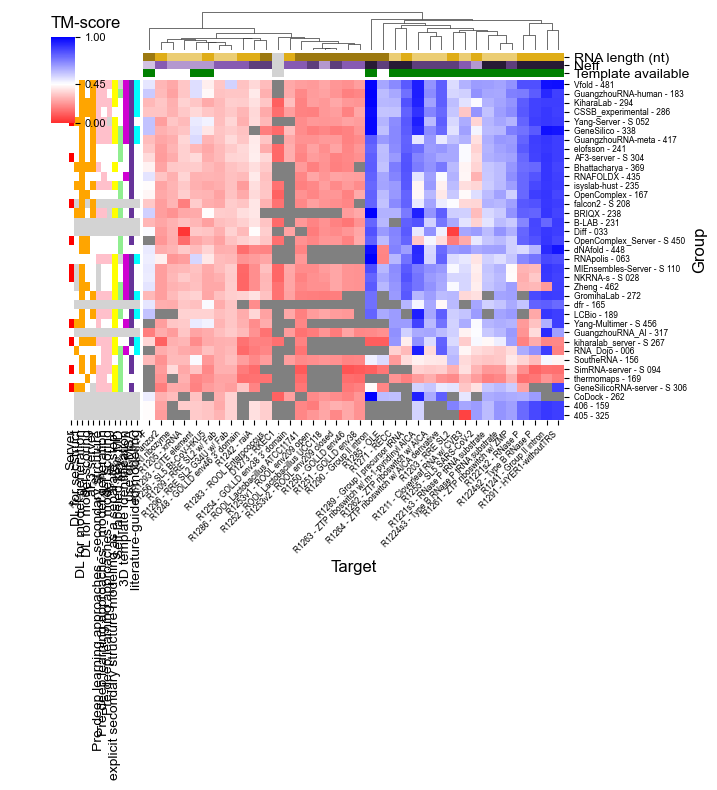

In [32]:
# Overview of perfomance plot
all_groups = best1_df['gr_code'].unique()
scores_df = best1_df[best1_df['Z_tm_score'] > 0].groupby('gr_code')['Z_tm_score'].sum()
scores = pd.Series(0, index=all_groups).add(scores_df, fill_value=0).sort_values(ascending=False)
#scores = scores.rank()

g=overview_performance_clustermap(y_axis = 'gr_code',
                                plot_df = df[~df.gr_code.isin(['998','999'])],
                                x_axis = 'target_full',
                                value = 'tm_score',
                                mid_value = 0.45,
                                participation_rate = 0.6,
                                score_name = 'TM-score',
                                target_colors = target_colors,
                                group_colors = group_colors,#GROUP_SERVER.Server_c,
                                save='figure_subpanels/clustermap_tm_score',
                               rotate_x=45,label_size=6,figsize=(8,8),
                               scores = scores) 
plt.show()

37
4 1.5 3 46
0.5587607753525266
2.75
{0: 0, 1: 1, 4: 2, 5: 3, 3: 4, 2: 5, 8: 6, 7: 7, 6: 8, 9: 9, 10: 10, 14: 11, 12: 12, 15: 13, 13: 14, 16: 15, 11: 16, 22: 17, 19: 18, 20: 19, 17: 20, 18: 21, 21: 22, 24: 23, 28: 24, 23: 25, 26: 26, 25: 27, 33: 28, 32: 29, 30: 30, 35: 31, 36: 32, 34: 33, 29: 34, 27: 35, 31: 36, 37: 20.5, 38: 7.5, 39: 10.5, 40: 0.5, 41: 11.25, 42: 2.5, 43: 6.75, 44: 12.125, 45: 7.875, 46: 1.5, 47: 10.0, 48: 2.75, 49: 18.5, 50: 3.875, 51: 31.5, 52: 21.25, 53: 6.9375, 54: 16.5, 55: 10.46875, 56: 26.5, 57: 12.734375, 58: 14.6171875, 59: 35.5, 60: 16.55859375, 61: 18.904296875, 62: 27.25, 63: 30.75, 64: 28.125, 65: 31.875, 66: 20.9521484375, 67: 22.47607421875, 68: 30.0, 69: 23.738037109375, 70: 26.8690185546875, 71: 30.43450927734375, 72: 32.967254638671875} {0: 0, 1: 0, 2: 0, 3: 0, 4: 0, 5: 0, 6: 0, 7: 0, 8: 0, 9: 0, 10: 0, 11: 0, 12: 0, 13: 0, 14: 0, 15: 0, 16: 0, 17: 0, 18: 0, 19: 0, 20: 0, 21: 0, 22: 0, 23: 0, 24: 0, 25: 0, 26: 0, 27: 0, 28: 0, 29: 0, 30: 0, 31: 0, 3

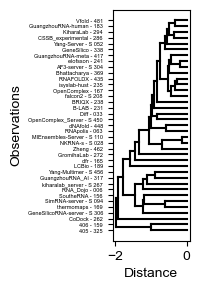

In [35]:
def custom_dendrogram(linkage_matrix, leaf_order,labels):
    """
    Plots a dendrogram based on the linkage matrix and specified leaf order.

    Parameters:
    linkage_matrix (numpy.ndarray): The linkage matrix (Nx4).
    leaf_order (list): List of indices specifying the order of leaves.
    """
    # Number of observations
    num_obs = linkage_matrix.shape[0] + 1
    print(num_obs)
    
    # Position mapping based on the leaf order
    #position = {leaf: i for i, leaf in enumerate(leaf_order)}
    positions = {pos:i for i, pos in enumerate(leaf_order)}
    heights = {i: 0 for i in range(num_obs)}
    
    # Initialize plot
    fig, ax = plt.subplots(figsize=(1, 3))
    
    # Loop through the linkage matrix to plot each merge
    for i, (cluster1, cluster2, dist, num_elems) in enumerate(linkage_matrix):
        cluster1 = int(cluster1)
        cluster2 = int(cluster2)
        
        # Positions of clusters on the x-axis based on leaf order
        #pos1 = position[cluster1] if cluster1 < num_obs else (position[int(linkage_matrix[cluster1 - num_obs, 0])])
        #pos2 = position[cluster2] if cluster2 < num_obs else (position[int(linkage_matrix[cluster2 - num_obs, 0])])
        
        #if cluster1 < num_obs and cluster2 < num_obs:
        #pos = [positions[cluster1], positions[cluster2]]
        #elif cluster1 < num_obs:
        #    pos = [position[cluster1],position[cluster1]]
        #elif cluster2 < num_obs:
        #    pos = [position[cluster2],position[cluster2]]
        #else:
        #    continue
        # Measure the height as the distance between clusters
        pos1 = positions[cluster1]
        pos2 = positions[cluster2]
        #height = dist
        
        # Plot horizontal line
        ax.plot([-dist, -dist],[-pos1, -pos2],  'k-')
        ax.plot([-heights[cluster1], -dist],[-pos1, -pos1],  'k-')
        ax.plot([-heights[cluster2], -dist],[-pos2, -pos2],  'k-')
        
        # Plot vertical lines
        #for p in pos:
        #    ax.plot([p,p], [height, 0], 'k-')
        
        # Update position mapping for the newly merged cluster
        #position[num_obs + i] = (pos1 + pos2) / 2
        new_pos = (pos1 + pos2) / 2
        new_cluster_idx = num_obs + i
        positions[new_cluster_idx] = new_pos
        heights[new_cluster_idx] = dist
        if cluster1 ==3:
            print(pos1,pos2,cluster1,cluster2)
            print(dist)
            print(new_pos)
    
    # Set labels and show plot
    ax.set_yticks([-1*x for x in range(len(labels))])
    ax.set_yticklabels(labels,rotation=0,fontsize=4)
    ax.set_ylabel('Observations')
    ax.set_xlabel('Distance')
    print(positions,heights)
    

custom_dendrogram(linkage_matrix,leaf_order,pivot_df.index)
plt.savefig(f"figure_subpanels/clustermap_tm_score_justden.svg",dpi=400, bbox_inches='tight', transparent=True)
plt.show()


In [36]:
af3 = best1_df.gr_code.isin(['998','999'])
rool = best1_df.target.isin(['R1252','R1253','R1253v1','R1253v2','R1283v1','R1283v2','R1283v3','R1286'])
best1_df[af3&rool]

,target,gr_code,lddt,tm_score,gdt_ts,inf_all,TM_align,inf_stack,inf_wc,inf_nwc,...,Z_global_rmsd,Z_clashscore,Z_clashes_number,Z_CASP15,Z_CASP16_t33_g33_l33,Z_CASP16_t30_g30_l40,Z_CASP16_t25_g25_l50,Z_CASP16_t20_g20_l60,Z_topo,Z_rmsd_inf
980,R1252,998,0.487,0.2351,0.087,NaN,0.2236,NaN,NaN,NaN,...,-0.393036,NaN,1.172611,NaN,1.050355,1.097399,1.167965,1.238531,0.815134,NaN
981,R1252,999,0.358,0.1482,0.061,NaN,0.1935,NaN,NaN,NaN,...,-3.624481,NaN,-0.014128,NaN,-3.501948,-3.458580,-3.393529,-3.328478,-3.718785,NaN
1009,R1253v1,998,0.473,0.1940,0.072,NaN,0.2072,NaN,NaN,NaN,...,-1.305603,NaN,0.920094,NaN,0.178713,0.274008,0.416951,0.559893,-0.297763,NaN
1010,R1253v1,999,0.328,0.1383,0.044,NaN,0.1930,NaN,NaN,NaN,...,-4.846012,NaN,0.999633,NaN,-2.355143,-2.295975,-2.207222,-2.118469,-2.650986,NaN
1038,R1253v2,998,0.460,0.1940,0.072,NaN,0.2096,NaN,NaN,NaN,...,-1.411021,NaN,0.837119,NaN,-0.082791,0.017247,0.167304,0.317362,-0.582982,NaN
1039,R1253v2,999,0.319,0.1395,0.045,NaN,0.2032,NaN,NaN,NaN,...,-4.468146,NaN,0.906756,NaN,-2.387353,-2.343008,-2.276490,-2.209972,-2.609079,NaN
1440,R1283v1,998,0.601,0.3175,0.164,NaN,0.3241,NaN,NaN,NaN,...,0.372342,NaN,0.147080,NaN,0.675021,0.655339,0.625816,0.596293,0.773430,NaN
1441,R1283v1,999,0.438,0.1968,0.111,NaN,0.2659,NaN,NaN,NaN,...,-1.420734,NaN,0.069422,NaN,-1.520765,-1.541944,-1.573712,-1.605480,-1.414872,NaN
1472,R1283v2,998,0.125,0.2572,0.026,NaN,0.2549,NaN,NaN,NaN,...,1.000000,NaN,1.000000,NaN,1.000000,1.000000,1.000000,1.000000,1.000000,NaN
1473,R1283v2,999,0.091,0.1720,0.018,NaN,0.2173,NaN,NaN,NaN,...,-1.000000,NaN,-1.000000,NaN,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,NaN


In [37]:
af3 = best1_df.gr_code.str.contains('304')
rool = best1_df.target.isin(['R1252','R1253','R1253v1','R1253v2','R1283v1','R1283v2','R1283v3','R1286'])
best1_df[af3&rool]

,target,gr_code,lddt,tm_score,gdt_ts,inf_all,TM_align,inf_stack,inf_wc,inf_nwc,...,Z_global_rmsd,Z_clashscore,Z_clashes_number,Z_CASP15,Z_CASP16_t33_g33_l33,Z_CASP16_t30_g30_l40,Z_CASP16_t25_g25_l50,Z_CASP16_t20_g20_l60,Z_topo,Z_rmsd_inf
982,R1252,AF3-server - S 304,0.447,0.220,0.07,0.70,0.267,0.72,0.78,0.43,...,-0.905596,-0.487340,-0.632221,-0.532022,-0.553354,-0.488235,-0.390558,-0.292881,-0.878945,-0.269754
1011,R1253v1,AF3-server - S 304,0.405,0.237,0.07,0.69,0.237,0.70,0.82,0.45,...,-0.124277,-0.523477,-0.813853,0.186626,0.172132,0.132314,0.072587,0.012860,0.371222,-0.269435
1040,R1253v2,AF3-server - S 304,0.424,0.183,0.07,0.70,0.218,0.70,0.82,0.45,...,-0.339782,-0.426728,-0.466090,-0.412081,-0.500855,-0.432070,-0.328892,-0.225714,-0.844781,0.321775
1442,R1283v1,AF3-server - S 304,0.619,0.365,0.15,0.67,0.412,0.65,0.77,0.60,...,1.415862,-0.395481,0.069422,0.793542,0.872959,0.857896,0.835302,0.812709,0.948271,1.076273
1513,R1286,AF3-server - S 304,0.468,0.184,0.07,0.67,0.208,0.69,0.74,0.38,...,-1.486240,-0.361459,0.047154,0.042205,0.100166,0.147088,0.217471,0.287854,-0.134445,-0.404405


# Figure 2 scatterplot

In [38]:
GR_CODE_TO_NAME_SERVER

{'006': 'RNA_Dojo - 006',
 '020': 'comppharmunibas - 020',
 '026': 'SwRI - 026',
 '028': 'NKRNA-s - S 028',
 '033': 'Diff - 033',
 '051': 'MULTICOM - 051',
 '052': 'Yang-Server - S 052',
 '055': 'LCDD-team - 055',
 '063': 'RNApolis - 063',
 '091': 'Huang-HUST - 091',
 '094': 'SimRNA-server - S 094',
 '110': 'MIEnsembles-Server - S 110',
 '143': 'dMNAfold - 143',
 '147': 'Zheng-Multimer - S 147',
 '156': 'SoutheRNA - 156',
 '159': '406 - 159',
 '165': 'dfr - 165',
 '167': 'OpenComplex - 167',
 '169': 'thermomaps - 169',
 '183': 'GuangzhouRNA-human - 183',
 '189': 'LCBio - 189',
 '202': 'test001 - 202',
 '207': 'MULTICOM_ligand - 207',
 '208': 'falcon2 - S 208',
 '227': 'KUMC - 227',
 '231': 'B-LAB - 231',
 '235': 'isyslab-hust - 235',
 '238': 'BRIQX - 238',
 '241': 'elofsson - 241',
 '261': 'UNRES - 261',
 '262': 'CoDock - 262',
 '267': 'kiharalab_server - S 267',
 '272': 'GromihaLab - 272',
 '276': 'FrederickFolding - 276',
 '286': 'CSSB_experimental - 286',
 '294': 'KiharaLab - 294',


tm_score
gdt_ts
lddt


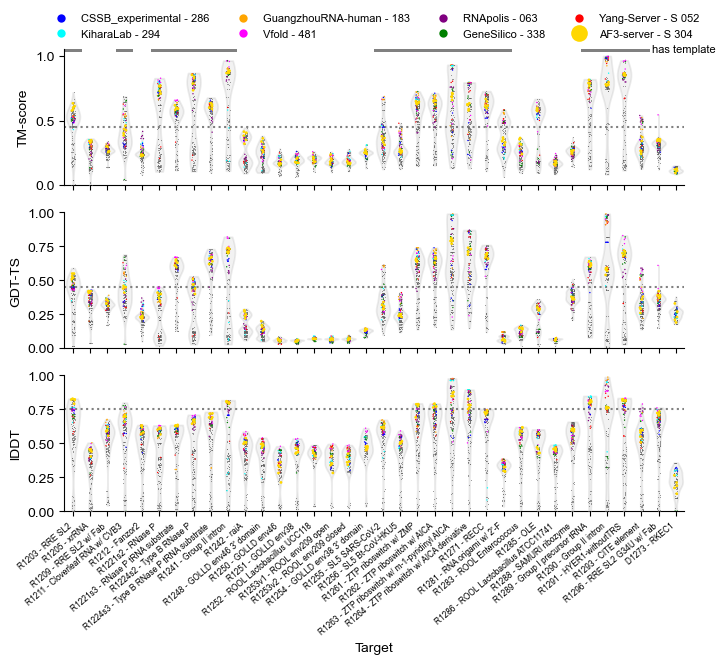

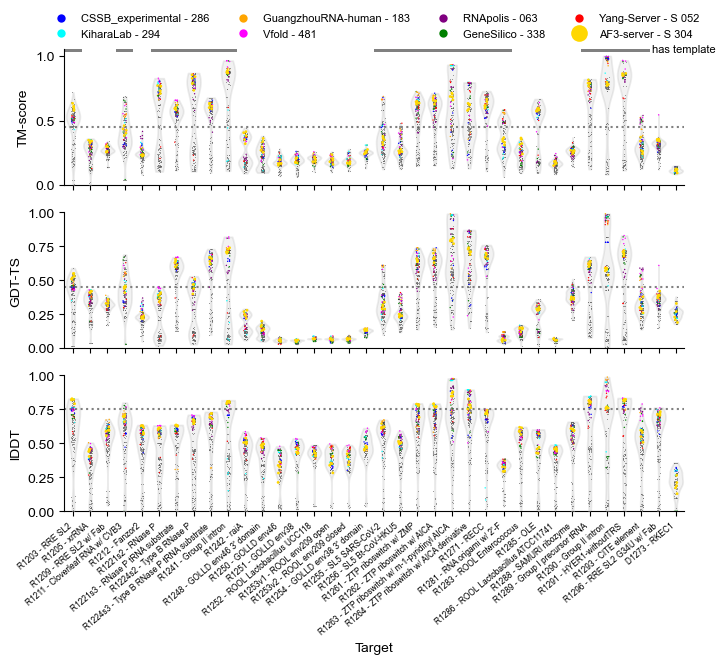

In [43]:
template_info = TEMPLATE_INFO[TEMPLATE_INFO.Competition == 'CASP16']
templates = template_info[template_info['Best Template TM align']>0.45].Target.to_list()


af3_performance = [df[df.gr_code_=='304'].groupby('target').tm_score.max().to_dict(),
                   df[df.gr_code_=='304'].groupby('target').gdt_ts.max().to_dict(),
                   df[df.gr_code_=='304'].groupby('target').lddt.max().to_dict(),]


metrics_to_plot = ['tm_score','gdt_ts','lddt']

fig,axes=plt.subplots(len(metrics_to_plot),1,figsize=(8,2*len(metrics_to_plot)),sharex=True)
labels = {'lddt':'lDDT','tm_score':'TM-score','gdt_ts':'GDT-TS','TM_align':'TM_align'}
for i,metric in enumerate(metrics_to_plot):
    print(metric)
    sns.violinplot(df,x='target',y=metric,color='grey',inner=None,ax=axes[i],alpha=0.1,density_norm='width',cut=0,order=MONOMER_TARGETS_TO_SCORETEMP)
    g=sns.stripplot(df[~df.gr_code.isin([GR_CODE_TO_NAME['304']]+list(GROUP_HIGHLIGHTS.keys()))],
                    x='target',y=metric,size=0.5, color='grey',ax=axes[i],order=MONOMER_TARGETS_TO_SCORETEMP)
    # swarmplot
    #for g,c in group_highlights.items():
    g=sns.stripplot(df[df.gr_code.isin(GROUP_HIGHLIGHTS.keys())],x='target',y=metric,size=1, 
                    hue='gr_code',palette=GROUP_HIGHLIGHTS,ax=axes[i],order=MONOMER_TARGETS_TO_SCORETEMP,legend=(i==0))
    g=sns.stripplot(df[df.gr_code==GR_CODE_TO_NAME_SERVER['304']],x='target',y=metric,size=2, 
                    hue='gr_code',palette={GR_CODE_TO_NAME_SERVER['304']:'gold'},ax=axes[i],
                    order=MONOMER_TARGETS_TO_SCORETEMP,legend=(i==0))
    
    if metric in METRIC_RANGES:
        g.set_ylim(METRIC_RANGES[metric][0],metric_ranges[metric][1])
    else:
        g.set_ylim(0,1)
    xmin,xmax = g.get_xlim()
    if metric in METRIC_PASS_SCORE:
        g.hlines(METRIC_PASS_SCORE[metric],xmin,xmax,"grey",":")
    g.set_xlim(xmin,xmax)
    g.set_xticks(g.get_xticks())
    g.set_ylabel(labels[metric])
    g.set_xticklabels(labels=[target_full_names[x] for x in MONOMER_TARGETS_TO_SCORETEMP],rotation = 40,size=6,ha='right')
    g.spines[['right', 'top']].set_visible(False)
sns.move_legend(axes[0], "lower center", bbox_to_anchor=(.5, 1), ncol=4, title=None, frameon=False,markerscale=6,fontsize=8)


import matplotlib.patches as patches

for tick in axes[0].get_xticks():

    if MONOMER_TARGETS_TO_SCORETEMP[tick] in templates:
        rect = patches.Rectangle((tick - 0.5, 1.05-0.02), 1, 0.02, facecolor='grey', edgecolor='none', clip_on=True)
    
        # Add rectangle to the axes
        axes[0].add_patch(rect)
axes[0].set_ylim(0,1.05)
axes[0].text(33.6,1.03,'has template',size=8)
axes[2].set_xlabel('Target')

plt.savefig("figure_subpanels/monomer_tm_gdt_lddt.svg",dpi=400, bbox_inches='tight', transparent=True)
plt.show()

# Figure 3 B-D scatter performance v difficulty

In [40]:
# get_best_pred_tm_align
not_to_analyse = ['D1273',
                  'R1253v1']
best_pred_tm_align = (df[~df.target.isin(not_to_analyse) & df.target.isin(MONOMER_TARGETS_TO_SCORE)]
                     .groupby('target').TM_align.max().reset_index())

# get templtate best tm align
best_pred_tm_align['template_tm'] = best_pred_tm_align.target.map(CASP16_TEMPLATE_DICT)

# get neff
best_pred_tm_align['neff'] = best_pred_tm_align.target.map(CASP16_NEFF)

# get rna length
best_pred_tm_align['rna_length'] = best_pred_tm_align.target.map(CASP16_LENGTH)
best_pred_tm_align.head()

,target,TM_align,template_tm,neff,rna_length
0,R1203,0.789,0.63008,859.305047,134.0
1,R1205,0.380,0.40238,9.071970,59.0
2,R1209,0.356,0.36336,45.651930,72.0
3,R1211,0.691,0.66418,89.133050,90.0
4,R1212,0.466,0.38932,86.600155,247.0


# Figure 3

In [41]:
not_to_analyse = ['D1273'] 
best_pred_tm_align = best1_df[~best1_df.target.isin(not_to_analyse)].groupby('target').TM_align.max().reset_index()
best_pred_tm_align['template_tm'] = best_pred_tm_align.target.map(CASP16_TEMPLATE_DICT)
best_pred_tm_align['rna_length'] = best_pred_tm_align.target.map(CASP16_LENGTH)
best_pred_tm_align['neff'] = best_pred_tm_align.target.map(CASP16_NEFF)
best_pred_tm_align.head()

# get rid of duplicate entries
best_pred_tm_align = best_pred_tm_align.set_index('target')
for targs in TARGETS_CHOOSE_BEST:
    conbine_targ = [x for x in targs if x in best_pred_tm_align.index]
    if len(conbine_targ)>1:
        new_row_series = pd.Series(best_pred_tm_align.loc[conbine_targ].max(), name='-'.join(conbine_targ)) 
        best_pred_tm_align = pd.concat([new_row_series.to_frame().T,best_pred_tm_align])
        best_pred_tm_align = best_pred_tm_align.drop(conbine_targ)
best_pred_tm_align.head()

,TM_align,template_tm,rna_length,neff
R1221s3-R1224s3,0.758,0.67102,86.0,1800.206409
R1241-R1291,0.969,0.97360,480.0,2057.053806
R1283v1-R1283v2-R1283v3,0.412,0.33413,580.0,281.428719
R1261-R1262,0.727,0.59501,89.0,725.454153
R1263-R1264,0.930,0.92993,64.0,554.144286


In [42]:
best_pred_tm_align.sort_values('neff')

,TM_align,template_tm,rna_length,neff
R1281,0.643,0.64405,718.0,1.000000
R1256,0.499,0.49284,127.0,2.985899
R1205,0.380,0.40238,59.0,9.071970
R1293,0.549,0.58925,82.0,11.213610
R1255,0.728,0.72986,124.0,14.384418
R1252,0.287,0.32455,520.0,15.876190
R1288,0.404,0.38376,58.0,19.026840
R1286,0.273,0.32875,526.0,34.333333
R1209,0.356,0.36336,72.0,45.651930
R1296,0.588,0.42965,72.0,47.881653


C:\Users\racha\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\racha\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\racha\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


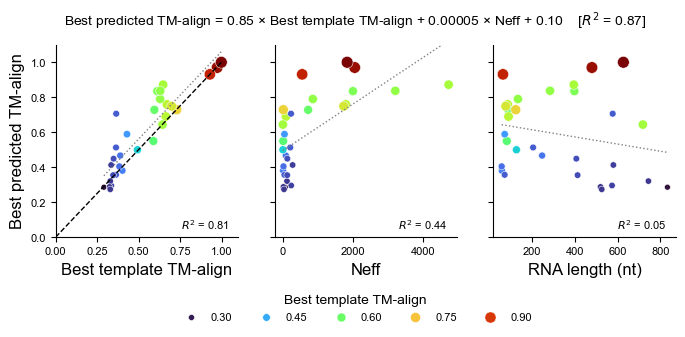

In [48]:
from sklearn.linear_model import LinearRegression

fig, axes = plt.subplots(1,3,figsize=(8,2.5),sharey=True)

variables = ['template_tm', 'neff', 'rna_length']
labels = ['Best template TM-align','Neff','RNA length (nt)']

axes[0].plot([0, 1], [0, 1], linestyle='--', color='black',linewidth=1)

for i in range(3):
    g=sns.scatterplot(best_pred_tm_align,x=variables[i],y='TM_align',ax=axes[i],
                hue='template_tm',size='template_tm',palette='turbo',legend=i==1) # 
    axes[i].set_ylim(0,1.1)
    axes[i].set_xlabel(labels[i],size=12)
    axes[i].set_ylabel('Best predicted TM-align',size=12)
    axes[i].tick_params(axis='both', which='major', labelsize=8) 
    axes[i].spines[['right', 'top']].set_visible(False)
    if i==1: axes[i].get_legend().remove()

    # Linear Regression and plotting
    X = best_pred_tm_align[[variables[i]]]
    y = best_pred_tm_align['TM_align']
    model = LinearRegression().fit(X, y)
    r2 = model.score(X, y)
    X_subset = np.array([X.min().item(),X.max().item()]).reshape(-1, 1)
    predicted = model.predict(X_subset)
    axes[i].plot(X_subset,predicted, color='grey',linestyle=':', linewidth=1)  # Line of best fit
    axes[i].text(0.95, 0.1, f'$R^2$ = {r2:.2f}', transform=axes[i].transAxes,
                 ha='right', va='top', fontsize=8)  # R-squared value


axes[0].set_xlim(0,1.1)
handles, labels = axes[1].get_legend_handles_labels()  #handles and labels are now in order
legend = fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=5, 
                    fontsize=8, title='Best template TM-align',title_fontsize=10,frameon=False)


# Fit linear model with first two variables
X = best_pred_tm_align[['template_tm', 'neff']]
y = best_pred_tm_align['TM_align']
model = LinearRegression().fit(X, y)
r2 = model.score(X, y)
coefficients = model.coef_
intercept = model.intercept_
equation = f"Best predicted TM-align = {coefficients[0]:.2f} × Best template TM-align + {coefficients[1]:.5f} × Neff + {intercept:.2f}    [$R^2$ = {r2:.2f}]"
axes[0].text(0.05, 1.3, equation, fontsize=10, va='top')



plt.savefig(f"figure_subpanels/casp16_rna_template_neff_length.png",dpi=400, bbox_inches='tight', transparent=True)
plt.savefig(f"figure_subpanels/casp16_rna_template_neff_length.svg",dpi=400, bbox_inches='tight', transparent=True)
plt.show()

# Figure 4 rankings

In [51]:
#best1_df['target_full'] = best1_df.target.map(target_full_names).unique()

100%|██████████| 1000/1000 [01:20<00:00, 12.40it/s]
C:\Users\racha\OneDrive\Desktop\CASP16_NA\NA_CASP_assessment\analysis\CASP16_NA_assessment.py:1247: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_all = df_copy.pivot_table(index=group_col, columns=target_col, values=score,


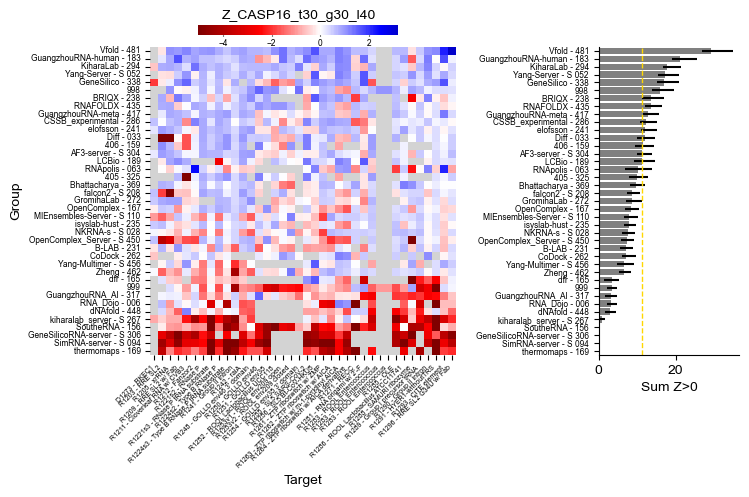

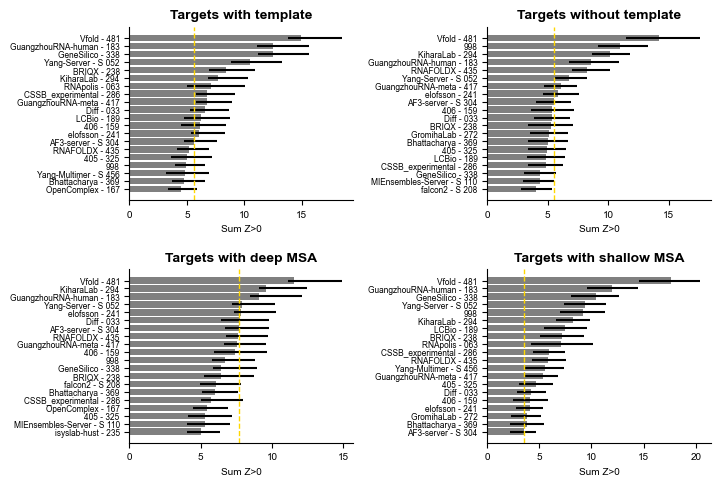

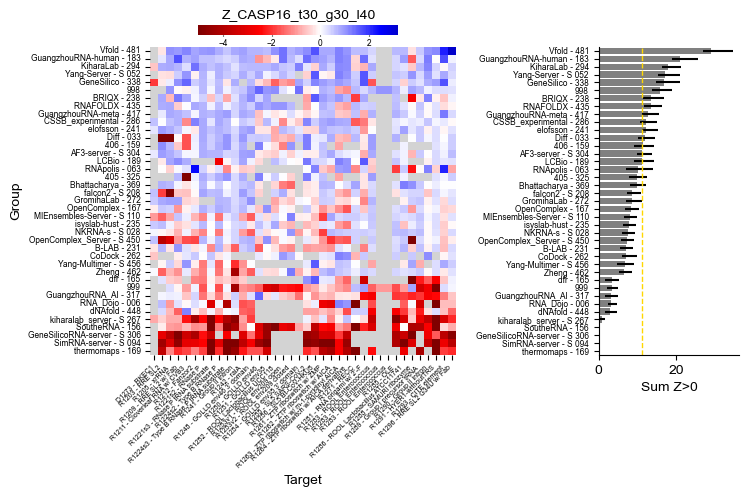

In [58]:
r,g,ci = plot_heat_map(best1_df,'Z_CASP16_t30_g30_l40',figsize=(7.6,5),
              targets_to_choose_best=TARGETS_CHOOSE_BEST,
              savefig='figure_subpanels/casp16_monomer_rankings.svg',
             num_bootstrap=1000,vmin=-5)
ax = plt.gcf().axes[0]
t=ax.set_xticklabels(labels=[target_full_names[x.get_text()] for x in ax.get_xticklabels()],rotation=45,size=5,ha='right')
plt.savefig('figure_subpanels/casp16_monomer_ranking_tareget_full.svg',dpi=400, bbox_inches='tight')
plt.show()

In [52]:
g['lower_bound'] = ci[0]
g['upper_bound'] = ci[1]
g.to_csv('summary_tables/final_Z_NA_monomer.csv')

In [53]:
print([x for x in best1_df.target.unique() if x not in TEMPLATE_TARGETS+NO_TEMPLATE_TARGETS])
print([x for x in best1_df.target.unique() if x not in MSA_TARGETS+NO_MSA_TARGETS])

['D1273']
['D1273']


100%|██████████| 1000/1000 [00:43<00:00, 23.11it/s]
C:\Users\racha\OneDrive\Desktop\CASP16_NA\NA_CASP_assessment\analysis\CASP16_NA_assessment.py:1401: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  t=ax.set_yticklabels(labels=ax.get_yticklabels(),size=tick_label_size)
C:\Users\racha\OneDrive\Desktop\CASP16_NA\NA_CASP_assessment\analysis\CASP16_NA_assessment.py:1402: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  t=ax.set_xticklabels(labels=ax.get_xticklabels(),size=tick_label_size*1.2)
100%|██████████| 1000/1000 [00:34<00:00, 28.92it/s]
C:\Users\racha\OneDrive\Desktop\CASP16_NA\NA_CASP_assessment\analysis\CASP16_NA_assessment.py:1401: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  t=ax.set_yticklabels(labels=ax.get_yticklabels(),size=tick_l

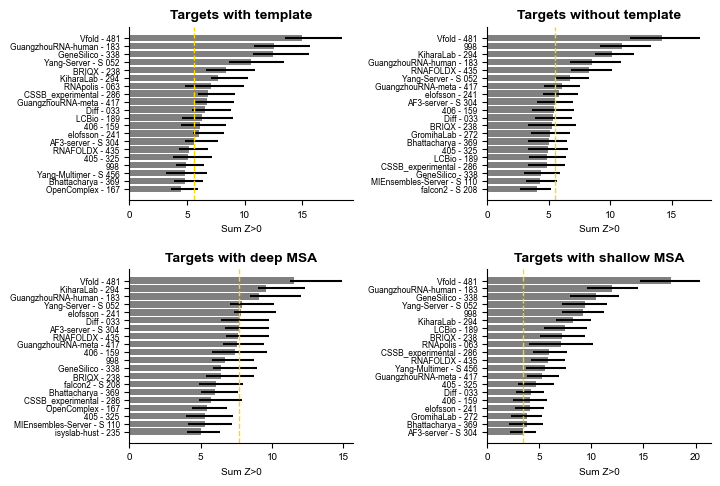

In [59]:
fig,axes = plt.subplots(2,2, figsize=(7.5, 5.4))
N=20
height=0.7
tick_label_size=6
num_bootstrap=1000
plot_top_n(best1_df[best1_df.target.isin(TEMPLATE_TARGETS)],'Z_CASP16_t30_g30_l40',
              targets_to_choose_best=TARGETS_CHOOSE_BEST,
           N=N,ax=axes[0,0],#height=height,
          h_bar_color='grey',tick_label_size=tick_label_size,
               num_bootstrap=num_bootstrap)

plot_top_n(best1_df[best1_df.target.isin(NO_TEMPLATE_TARGETS)],'Z_CASP16_t30_g30_l40',
              targets_to_choose_best=TARGETS_CHOOSE_BEST,
           N=N,ax=axes[0,1],#height=height,
          h_bar_color='grey',tick_label_size=tick_label_size,
               num_bootstrap=num_bootstrap)

plot_top_n(best1_df[best1_df.target.isin(MSA_TARGETS)],'Z_CASP16_t30_g30_l40',
              targets_to_choose_best=TARGETS_CHOOSE_BEST,
           N=N,ax=axes[1,0],#height=height,
          h_bar_color='grey',tick_label_size=tick_label_size,
               num_bootstrap=num_bootstrap)
plot_top_n(best1_df[best1_df.target.isin(NO_MSA_TARGETS)],'Z_CASP16_t30_g30_l40',
              targets_to_choose_best=TARGETS_CHOOSE_BEST,
           N=N,ax=axes[1,1],#height=height,
          h_bar_color='grey',tick_label_size=tick_label_size,
               num_bootstrap=num_bootstrap)

axes[0,0].set_title('Targets with template',size=10, fontweight='bold')
axes[0,1].set_title('Targets without template',size=10, fontweight='bold')
axes[1,0].set_title('Targets with deep MSA',size=10, fontweight='bold')
axes[1,1].set_title('Targets with shallow MSA',size=10, fontweight='bold')

plt.subplots_adjust(wspace=0.6,hspace=0.4)
plt.savefig('figure_subpanels/casp16_monomer_ranking_templated_msa.svg',dpi=400, bbox_inches='tight')
plt.show()

In [60]:
print(len(NO_MSA_TARGETS))
print(len(MSA_TARGETS))
print(len(NO_TEMPLATE_TARGETS))
print(len(TEMPLATE_TARGETS))

16
23
18
19


In [61]:
NO_TEMPLATE_TARGETS

['R1205',
 'R1209',
 'R1212',
 'R1242',
 'R1248',
 'R1254',
 'R1252',
 'R1253v2',
 'R1286',
 'R1250',
 'R1251',
 'R1288',
 'R1283v1',
 'R1296',
 'R1285',
 'R1253v1',
 'R1283v2',
 'R1283v3']

In [62]:
MSA_TARGETS

['R1203',
 'R1221s2',
 'R1221s3',
 'R1224s2',
 'R1224s3',
 'R1241',
 'R1242',
 'R1253',
 'R1261',
 'R1262',
 'R1263',
 'R1264',
 'R1271',
 'R1283',
 'R1285',
 'R1289',
 'R1290',
 'R1291',
 'R1253v1',
 'R1253v2',
 'R1283v1',
 'R1283v2',
 'R1283v3']

# Supp fig 3 ranking comparison

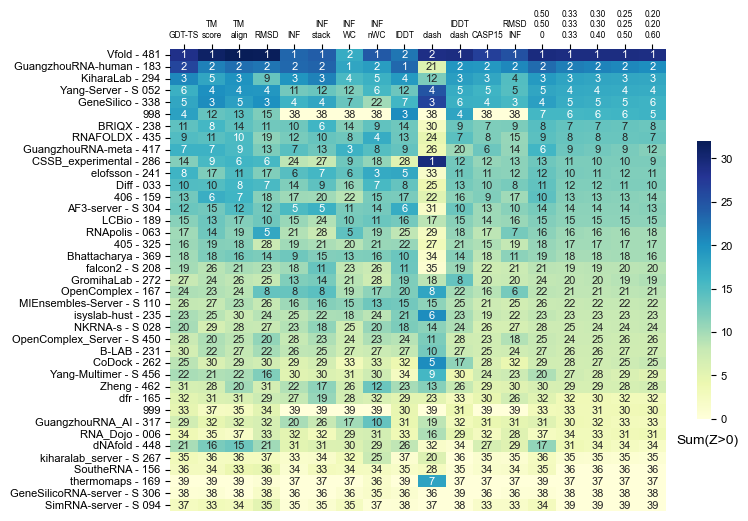

In [67]:
# get overall_rank
overall_metric = 'Z_CASP16_t30_g30_l40'

# get group scores, sum > 0
group_score = get_group_score(best1_df,
                              score=overall_metric,
                              targets_to_choose_best=TARGETS_CHOOSE_BEST)
# get rank with tiebreaker as the average score
group_score["tie"] = get_group_score(best1_df,score=overall_metric,agg="mean",targets_to_choose_best=TARGETS_CHOOSE_BEST)[overall_metric]
rank_ = group_score.sort_values([overall_metric,'tie'], ascending=False).gr_code.values
group_score_df = pd.DataFrame(rank_,columns=["gr_code"])
group_rank_df = pd.DataFrame(rank_,columns=["gr_code"])

# temp just do all
cols = ['Z_gdt_ts','Z_tm_score',   'Z_TM_align',  'Z_global_rmsd',
        'Z_inf_all','Z_inf_stack', 'Z_inf_wc', 'Z_inf_nwc', 'Z_lddt_no_checks', 'Z_clashscore', 'Z_lddt',  
        'Z_CASP15', 'Z_rmsd_inf', 'Z_topo', 
        'Z_CASP16_t33_g33_l33', 'Z_CASP16_t30_g30_l40', 'Z_CASP16_t25_g25_l50', 'Z_CASP16_t20_g20_l60',]

for metric in cols:
    # get group scores, sum > 0
    group_score = get_group_score(best1_df,score=metric,targets_to_choose_best=TARGETS_CHOOSE_BEST)
    # get rank with tiebreaker as the average score
    group_score_df = group_score_df.merge(group_score,on="gr_code")
    group_score["tie"] = get_group_score(best1_df,agg="mean",score=metric,targets_to_choose_best=TARGETS_CHOOSE_BEST)[metric]
    rank = group_score.sort_values([metric,'tie'], ascending=False).gr_code.values    
    group_rank_df[metric] = group_rank_df.gr_code.apply(lambda x: np.where(rank==x)[0][0]+1)
group_score_df = group_score_df.set_index("gr_code")
group_rank_df = group_rank_df.set_index("gr_code")
labels = {"rna":"ZRNA","tm_score":"TM\nscore","TM_align":"TM\nalign","gdt_ts":"GDT-TS","global_rmsd":"RMSD",
          "local":"Zlocal","inf_all":"INF","lddt":"lDDT\nclash","lddt_no_checks":"lDDT",
          "clashscore":"clash","CASP15":"CASP15","CASP16":"CASP16","topo":"0.50\n0.50\n0",
         'CASP16_t33_g33_l33':'0.33\n0.33\n0.33','CASP16_t30_g30_l40':'0.30\n0.30\n0.40', 
          'CASP16_t25_g25_l50':'0.25\n0.25\n0.50', 'CASP16_t20_g20_l60':'0.20\n0.20\n0.60',
         "inf_nwc":"INF\nnWC","inf_wc":"INF\nWC","inf_stack":"INF\nstack","rmsd_inf":"RMSD\nINF"}
prefix = 'Z_'
labels = {prefix+key:val for key,val in labels.items()}
group_score_df = group_score_df.rename(columns=labels)


plt.figure(figsize=(8,6))
from matplotlib.colors import LinearSegmentedColormap
cmap = "YlGnBu"#LinearSegmentedColormap.from_list('x',['white','green'])
g = sns.heatmap(group_score_df,cmap=cmap,annot=group_rank_df,cbar_kws={'shrink': 0.6},
               annot_kws={"size":8},yticklabels=group_score_df.index)
t=g.set_yticklabels(labels=g.get_yticklabels(),rotation = 0,size=8)
t=g.set_xticklabels(labels=g.get_xticklabels(),rotation = 0,size=6)
g.set_ylabel("")
cbar = g.collections[0].colorbar
cbar.ax.tick_params(labelsize=8)
cbar.set_label("Sum(Z>0)",size=10,ha='right',x=0,y=-0.1, rotation=0, va='bottom')
g.xaxis.tick_top()
plt.savefig("figure_subpanels/Zrank_bymetric_allmonomers.png",dpi=400, bbox_inches='tight', transparent=True)
plt.savefig("figure_subpanels/Zrank_bymetric_allmonomers.svg",dpi=400, bbox_inches='tight', transparent=True)
plt.show()

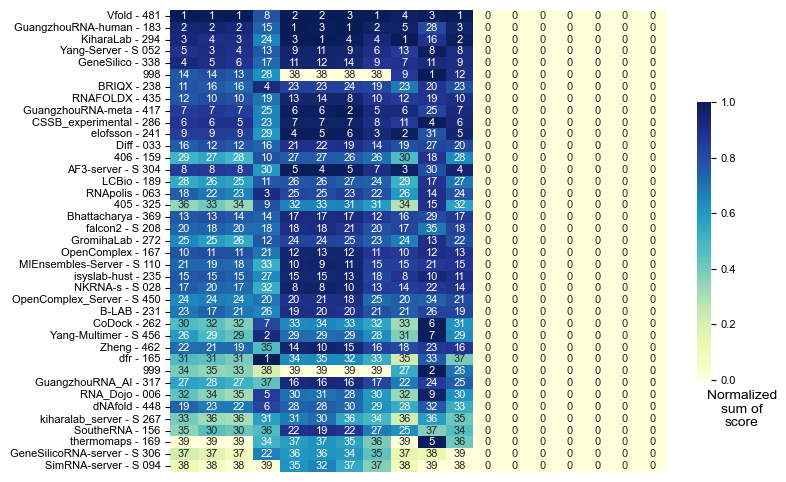

In [68]:
cols = ['gdt_ts','tm_score',   'TM_align',  'global_rmsd',
        'inf_all','inf_stack', 'inf_wc', 'inf_nwc', 'lddt_no_checks', 'clashscore', 'lddt',  
        ]
group_score = get_group_score(best1_df,
                              score=overall_metric,
                              targets_to_choose_best=TARGETS_CHOOSE_BEST)
# get rank with tiebreaker as the average score
group_score["tie"] = get_group_score(best1_df,score=overall_metric,agg="mean",targets_to_choose_best=TARGETS_CHOOSE_BEST)[overall_metric]
rank_ = group_score.sort_values([overall_metric,'tie'], ascending=False).gr_code.values
group_score_df = pd.DataFrame(rank_,columns=["gr_code"])
group_rank_df = pd.DataFrame(rank_,columns=["gr_code"])
for metric in cols:
    # get group scores, sum > 0
    group_score = get_group_score(best1_df,score=metric,agg='sum',targets_to_choose_best=TARGETS_CHOOSE_BEST)
    # 0 to 1 normalize for the coloring
    group_score[metric] = (group_score[metric] - group_score[metric].min())/ (group_score[metric].max()-group_score[metric].min())
    if metric in ['global_rmsd','clashscore']: group_score[metric] = 1-group_score[metric]
    # get rank with tiebreaker as the average score
    group_score_df = group_score_df.merge(group_score,on="gr_code")
    group_score["tie"] = get_group_score(best1_df,agg="mean",score=metric,targets_to_choose_best=TARGETS_CHOOSE_BEST)[metric]
    rank = group_score.sort_values([metric,'tie'], ascending=False).gr_code.values    
    group_rank_df[metric] = group_rank_df.gr_code.apply(lambda x: np.where(rank==x)[0][0]+1)
group_score_df = group_score_df.set_index("gr_code")
group_rank_df = group_rank_df.set_index("gr_code")

group_score_df = group_score_df.rename(columns=labels)
for i in range(7):
    group_score_df[i]=0
    group_rank_df[i]=0

plt.figure(figsize=(8,6))
from matplotlib.colors import LinearSegmentedColormap
cmap = "YlGnBu"#LinearSegmentedColormap.from_list('x',['white','green'])
g = sns.heatmap(group_score_df,cmap=cmap,annot=group_rank_df,cbar_kws={'shrink': 0.6},
               annot_kws={"size":8},yticklabels=group_score_df.index,vmax=1,vmin=0)
t=g.set_yticklabels(labels=g.get_yticklabels(),rotation = 0,size=8)
t=g.set_xticks(ticks=[],labels=[],rotation = 0,size=6)
g.set_ylabel("")
cbar = g.collections[0].colorbar
cbar.ax.tick_params(labelsize=8)
cbar.set_label("Normalized\nsum of\nscore",size=10,y=-0.18, rotation=0, va='bottom',ha='center')
g.xaxis.tick_top()
plt.savefig("figure_subpanels/Sumrank_bymetric_allmonomers.png",dpi=400, bbox_inches='tight', transparent=True)
plt.savefig("figure_subpanels/Sumrank_bymetric_allmonomers.svg",dpi=400, bbox_inches='tight', transparent=True)
plt.show()

# Supp fig comparison of metrics

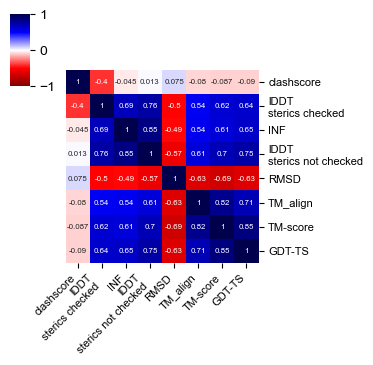

In [69]:
# plot score correlations
corr_total = None
nonnan_count = None

# over all target
for target in df.target.unique():
    # get spearman correlation of just the puzzle and the columns you want
    mets = list(METRICS.keys())
    for rm_metric in ['clashes_number','inf_stack','inf_wc','inf_nwc']: #'TM_align'
        mets.remove(rm_metric)
    x = df[df.target==target][mets].copy() #.apply(lambda x: -x if METRICS[x.name]=="min" else x)
    corr = x.corr(method="spearman")
    # get non-nan number
    count = ~np.isnan(corr)
    corr[~count] = 0
    if corr_total is not None:
        corr_total += corr
        nonnan_count += count.astype(int)
    else: 
        corr_total = corr
        nonnan_count = count.astype(int)

corr_avg = corr_total/nonnan_count
corr_avg = corr_avg.rename(columns=METRICS_LABELS,index=METRICS_LABELS)
g = sns.clustermap(corr_avg, vmin=-1, vmax=1,cmap="seismic_r",figsize=(4,4),
                   metric=lambda u,v:min(np.linalg.norm(u - v),np.linalg.norm(u + v)),
                   method='complete',tree_kws={"color":"white"},annot=True,
                  annot_kws={"size":5.7})
l=plt.setp(g.ax_heatmap.xaxis.get_majorticklabels(), rotation=45,ha="right",size=8)
l=plt.setp(g.ax_heatmap.yaxis.get_majorticklabels(), rotation=0,size=8)
plt.savefig("figure_subpanels/metric_correlation_monomer.svg",dpi=400, bbox_inches='tight', transparent=True)
plt.show()

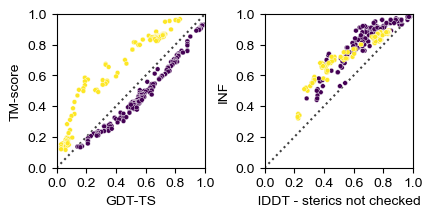

In [70]:
fig,axes = plt.subplots(1,2,figsize=(4.6,2))
df['rna_length'] = df.target.map(CASP16_LENGTH)
sns.scatterplot(df[df.target.isin(['R1291','R1263'])],x='gdt_ts',
                y='tm_score',hue='rna_length',palette='viridis',
                legend=False,s=12,ax=axes[0])
axes[0].set_xlim(0,1)
axes[0].set_ylim(0,1)
axes[0].set_xlabel('GDT-TS')
axes[0].set_ylabel('TM-score')
axes[0].plot([0,1], [0,1], 'k:', alpha=0.75, zorder=0)
axes[0].set_xticks(np.arange(0, 1.1, 0.2))
axes[0].set_yticks(np.arange(0, 1.1, 0.2))
sns.scatterplot(df[df.target.isin(['R1291','R1263'])],x='lddt_no_checks',
                y='inf_all',hue='rna_length',palette='viridis',
                legend=False,s=12,ax=axes[1])
axes[1].set_xlim(0,1)
axes[1].set_ylim(0,1)
axes[1].set_xlabel('lDDT - sterics not checked')
axes[1].set_ylabel('INF')
axes[1].plot([0,1], [0,1], 'k:', alpha=0.75, zorder=0)
plt.subplots_adjust(wspace=0.4)
axes[1].set_xticks(np.arange(0, 1.1, 0.2))
axes[1].set_yticks(np.arange(0, 1.1, 0.2))
plt.savefig("figure_subpanels/tm-gdt_bysize_monomer_select.svg",dpi=400, bbox_inches='tight', transparent=True)
plt.show()

# Figure X

In [39]:
print(MSA_TARGETS)
print(len(MSA_TARGETS))
TEMPLATE_TARGETS

['R1203', 'R1221s2', 'R1221s3', 'R1224s2', 'R1224s3', 'R1241', 'R1242', 'R1248', 'R1250', 'R1253', 'R1254', 'R1261', 'R1262', 'R1263', 'R1264', 'R1271', 'R1283', 'R1285', 'R1289', 'R1290', 'R1291']
21


['R1203',
 'R1211',
 'R1221s2',
 'R1221s3',
 'R1224s2',
 'R1224s3',
 'R1241',
 'R1255',
 'R1256',
 'R1261',
 'R1262',
 'R1263',
 'R1264',
 'R1271',
 'R1289',
 'R1291',
 'R1293',
 'R1281',
 'R1290']

In [40]:
NO_TEMPLATE_TARGETS

['R1205',
 'R1209',
 'R1212',
 'R1242',
 'R1248',
 'R1254',
 'R1252',
 'R1253v2',
 'R1286',
 'R1250',
 'R1251',
 'R1288',
 'R1283v1',
 'R1296',
 'R1285',
 'R1253v1',
 'R1283v2',
 'R1283v3']

In [38]:
best_pred_tm_align.sort_values('neff')

,TM_align,template_tm,rna_length,neff,neff_log10
R1281,0.643,0.64405,718.0,1.000000,0.000000
R1256,0.499,0.49284,127.0,2.985899,0.475075
R1205,0.380,0.40238,59.0,9.071970,0.957702
R1293,0.549,0.58925,82.0,11.213610,1.049745
R1255,0.728,0.72986,124.0,14.384418,1.157892
R1252,0.287,0.32455,520.0,15.876190,1.200746
R1288,0.404,0.38376,58.0,19.026840,1.279367
R1286,0.273,0.32875,526.0,34.333333,1.535716
R1209,0.356,0.36336,72.0,45.651930,1.659459
R1296,0.588,0.42965,72.0,47.881653,1.680169
